# **Deney: Otokodlayıcıların Oluşturulması**


## Öğrenim Hedefleri

Bu laboratuvarın sonunda şunları yapabileceksiniz: 

- Bir otoenkoder eğitmek için MNIST veri setini yükleyecek ve ön işleme tabi tutacaksınız. 

- Keras işlevsel API'sini kullanarak basit bir otoenkoder modeli oluşturacaksınız. 

- Otomatik kodlayıcıyı MNIST veri seti üzerinde eğiteceksiniz. 

- Eğitilmiş otomatik kodlayıcının performansını değerlendireceksiniz. 

- Performansını iyileştirmek için otomatik kodlayıcıyı ince ayarlayacaksınız. 

- Görüntülerdeki gürültüyü gidermek için otomatik kodlayıcıyı kullanacaksınız. 

Translated with DeepL.com (free version)

----


### Adım Adım Talimatlar: 

#### Adım 1: Veri Ön İşleme 

Bu alıştırmada, piksel değerleri normalize edilerek ve görüntüler düzleştirilerek MNIST veri kümesi eğitim için hazırlanmaktadır. Normalleştirme, eğitim sırasında daha hızlı yakınsama sağlanmasına yardımcı olur; düzleştirme ise, otoenkoderimizin giriş katmanının tek boyutlu bir vektör beklemesi nedeniyle gereklidir. 

In [1]:
!pip install tensorflow==2.16.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.8/590.8 MB 10.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 149.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 131.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 48.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 48.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 57.5 MB/s eta 0:00:00


In [2]:
import numpy as np 
from tensorflow.keras.datasets import mnist 

# Load the dataset 
(x_train, _), (x_test, _) = mnist.load_data() 

# Normalize the pixel values 
x_train = x_train.astype('float32') / 255. 
x_test = x_test.astype('float32') / 255. 

# Flatten the images 
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) 
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) 

2026-03-30 13:48:31.927587: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-30 13:48:31.928922: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-30 13:48:31.934109: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-30 13:48:31.947799: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-30 13:48:31.973499: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registe

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Yukarıdaki kodda:
- MNIST veri kümesini yüklemek için Keras kullanılır.
- Görüntü piksel değerleri [0, 1] aralığına normalize edilir.
- Verilerin biçimini değiştirmek için 28x28 boyutundaki görüntüler 784 boyutlu bir vektöre düzleştirilir. 

#### 2. Adım: Otokodlayıcı Modelinin Oluşturulması 

Bu alıştırmada, girdiyi 32 boyuta sıkıştıran bir kodlayıcı ve bu 32 boyuttan girdiyi yeniden oluşturan bir kod çözücü içeren bir otokodlayıcı oluşturulacaktır. Model, Adam optimizörü ve ikili çapraz entropi kayıp fonksiyonu kullanılarak derlenmiştir. 

In [3]:
from tensorflow.keras.models import Model 
from tensorflow.keras.layers import Input, Dense 

# Encoder 
input_layer = Input(shape=(784,)) 
encoded = Dense(64, activation='relu')(input_layer) 

# Bottleneck 
bottleneck = Dense(32, activation='relu')(encoded) 

# Decoder 
decoded = Dense(64, activation='relu')(bottleneck) 
output_layer = Dense(784, activation='sigmoid')(decoded) 

# Autoencoder model 
autoencoder = Model(input_layer, output_layer) 

# Compile the model 
autoencoder.compile(optimizer='adam', loss='binary_crossentropy') 

# Summary of the model 
autoencoder.summary() 

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,392 (411.69 KB)

 Trainable params: 105,392 (411.69 KB)

 Non-trainable params: 0 (0.00 B)

Yukarıdaki kodda: 

**1. Kodlayıcıyı tanımlayın:**
- 784 nöronlu bir giriş katmanı oluşturun. 
- 64 nöronlu ve ReLU aktivasyonlu bir Yoğun katman ekleyin. 

**2. Darboğazı tanımlayın:**
- 32 nöronlu ve ReLU aktivasyonlu bir Dense katmanı ekleyin. 

**3. Dekoderi tanımlayın:**
- 64 nöronlu ve ReLU aktivasyonlu bir Dense katmanı ekleyin. 
- 784 nöronlu ve sigmoid aktivasyonlu bir çıktı katmanı ekleyin. 

**4. Modeli derleyin:**
- Adam optimizörü ve ikili çapraz entropi kaybını kullanın.  

#### 3. Adım: Otokodlayıcının Eğitilmesi 

Bu alıştırmada, otokodlayıcı MNIST görüntülerini yeniden oluşturmak üzere eğitilir. Otokodlayıcı, girdiyi kendisine eşlemeye öğrendiği için, eğitim verileri hem girdi hem de hedef olarak kullanılır. 

In [4]:
autoencoder.fit(
    x_train, x_train,  
    epochs=25,  
    batch_size=256,  
    shuffle=True,  
    validation_data=(x_test, x_test)
)

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - loss: 0.2515 - val_loss: 0.1682
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1533 - val_loss: 0.1390
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1312 - val_loss: 0.1221
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1194 - val_loss: 0.1139
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1129 - val_loss: 0.1096
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1095 - val_loss: 0.1066
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1071 - val_loss: 0.1047
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1053 - val_loss: 0.1030
Epoch 9/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1035 - val_loss: 0.1015
Epoch 10/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1020 - val_loss: 0.1000
Epoch 11/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1007 - val_loss: 0.0987
Epoch 12/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 

Yukarıdaki kodda:
- Modeli eğitim verileriyle eğitmek için `fit` yöntemini kullanın.
- Epoç sayısını 25, parti boyutunu ise 256 olarak ayarlayın.
- Doğrulama için test verilerini kullanın. 

#### 4. Adım: Otokodlayıcının Değerlendirilmesi 

Bu alıştırmada, test görüntüleri yeniden oluşturulup orijinal görüntülerle karşılaştırılarak otokodlayıcı değerlendirilmektedir. Görselleştirme, otokodlayıcının girdi verilerini yeniden oluşturmayı ne kadar iyi öğrendiğini anlamaya yardımcı olur. 

In [6]:
!pip install matplotlib==3.9.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 126.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 151.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 168.8 MB/s eta 0:00:00


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  


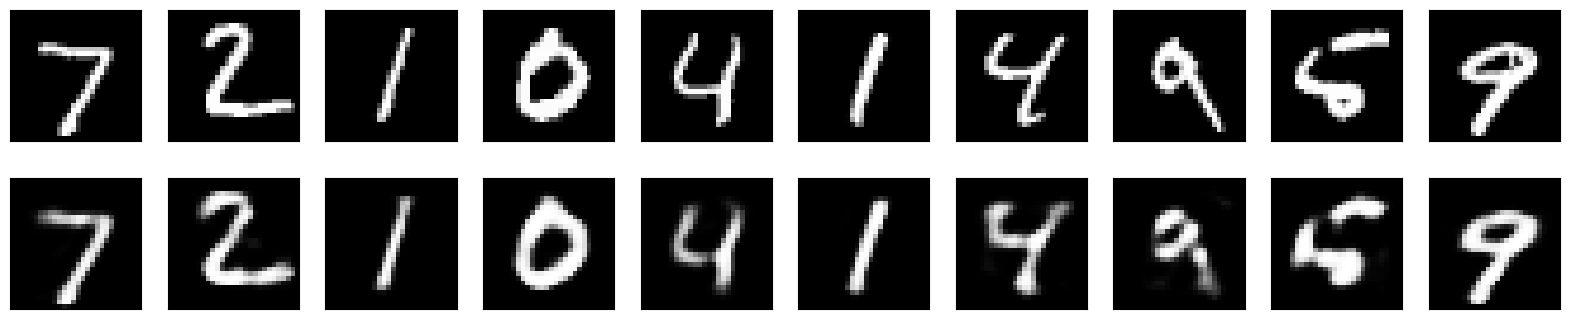

In [7]:
import matplotlib.pyplot as plt 

# Predict the test data 
reconstructed = autoencoder.predict(x_test) 

# Visualize the results 
n = 10  # Number of digits to display 
plt.figure(figsize=(20, 4)) 

for i in range(n): 
    # Display original 
    ax = plt.subplot(2, n, i + 1) 
    plt.imshow(x_test[i].reshape(28, 28)) 
    plt.gray() 
    ax.get_xaxis().set_visible(False) 
    ax.get_yaxis().set_visible(False) 

    # Display reconstruction 
    ax = plt.subplot(2, n, i + 1 + n) 
    plt.imshow(reconstructed[i].reshape(28, 28)) 
    plt.gray() 
    ax.get_xaxis().set_visible(False) 
    ax.get_yaxis().set_visible(False) 

plt.show()


Yukarıdaki kodda: 

**1. Görüntüleri Yeniden Oluşturma:**
- Test verilerini tahmin etmek için otomatik kodlayıcıyı kullanın. 
- Orijinal test görüntülerini yeniden oluşturulan görüntülerle karşılaştırın. 

**2. Sonuçları Görselleştirme:**
- Orijinal ve yeniden oluşturulan görüntülerden birkaç örneği yan yana grafikte gösterin. 

#### 5. Adım: Otokodlayıcının İnce Ayarının Yapılması 

Bazı katmanların dondurulmasını kaldırarak otokodlayıcının ince ayarını yapmak, performansını artırmaya yardımcı olabilir. Bu alıştırmada, son dört katmanın dondurulmasını kaldıracak ve modeli birkaç döngü daha eğiteceksiniz.

In [8]:
# Freeze all layers of the autoencoder
for layer in autoencoder.layers:
    layer.trainable = False


In [9]:
# Check trainable status of each layer
for i, layer in enumerate(autoencoder.layers):
    print(f"Layer {i}: {layer.name}, Trainable = {layer.trainable}")


Layer 0: input_layer, Trainable = False
Layer 1: dense, Trainable = False
Layer 2: dense_1, Trainable = False
Layer 3: dense_2, Trainable = False
Layer 4: dense_3, Trainable = False


In [10]:
# Unfreeze the top layers of the encoder
for layer in autoencoder.layers[-4:]: 
    layer.trainable = True 

# Compile the model again
autoencoder.compile(optimizer='adam', loss='binary_crossentropy') 

# Train the model again
autoencoder.fit(x_train, x_train,  
                epochs=10,  
                batch_size=256,  
                shuffle=True,  
                validation_data=(x_test, x_test))


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.0935 - val_loss: 0.0916
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0926 - val_loss: 0.0915
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0924 - val_loss: 0.0914
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0923 - val_loss: 0.0911
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0922 - val_loss: 0.0912
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0921 - val_loss: 0.0910
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0919 - val_loss: 0.0911
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0918 - val_loss: 0.0908
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0916 - val_loss: 0.0906
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0915 - val_loss: 0.0906


Yukarıdaki kodda: 

**1. Tüm Kodlayıcı Katmanlarını Dondurun:**
- Kodlayıcının tüm katmanlarını dondurun.

**2. Durumu kontrol edin:**
- Her katmanın eğitilebilir durumunu kontrol edin. 

**3. Kodlayıcı Katmanlarının Dondurmasını Kaldırın:**
- Kodlayıcının son dört katmanının dondurmasını kaldırın. 

**4. Modeli Derleyin ve Eğitin:**
- Modeli yeniden derleyin. 
- Modeli aynı eğitim ve doğrulama verileriyle 10 döngü boyunca yeniden eğitin.

#### 6. Adım: Otomatik Kodlayıcı ile Görüntülerdeki Gürültüyü Giderme 

Bu alıştırmada, veri kümesine rastgele gürültü ekleyecek ve otomatik kodlayıcıyı görüntülerin gürültüsünü gidermek üzere eğiteceksiniz. Otomatik kodlayıcı, gürültülü girdiden orijinal görüntüleri yeniden oluşturmayı öğrenir; bu süreç, gürültülü, gürültüsü giderilmiş ve orijinal görüntüleri karşılaştırarak görselleştirilebilir. 

Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.1732 - val_loss: 0.1448
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.1402 - val_loss: 0.1349
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.1334 - val_loss: 0.1304
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.1300 - val_loss: 0.1282
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.1279 - val_loss: 0.1265
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.1265 - val_loss: 0.1252
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.1255 - val_loss: 0.1242
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.1248 - val_loss: 0.1240
Epoch 9/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.1242 - val_loss: 0.1234
Epoch 10/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.1237 - val_loss: 0.1229
Epoch 11/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.1233 - val_loss: 0.1226
Epoch 12/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 

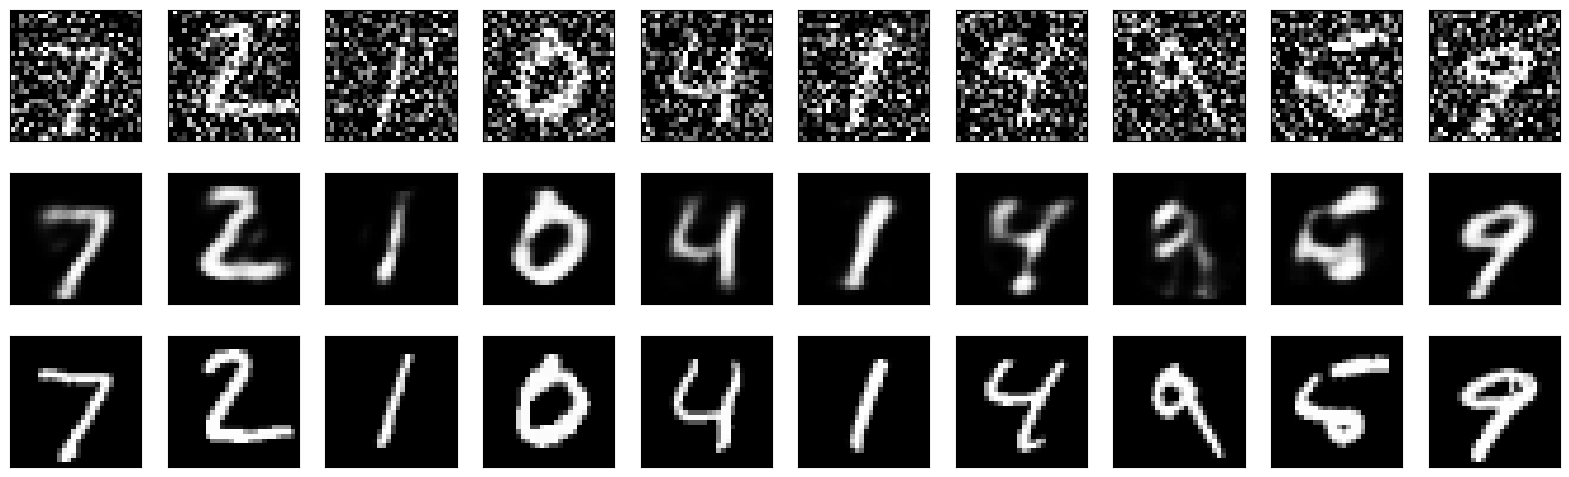

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Add noise to the data
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Train the autoencoder with noisy data
autoencoder.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=512,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

# Denoise the test images
reconstructed_noisy = autoencoder.predict(x_test_noisy)

# Visualize the results
n = 10  # Number of digits to display
plt.figure(figsize=(20, 6))
for i in range(n):
    # Display noisy images
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    # Display denoised images
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(reconstructed_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display original images
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()


Yukarıdaki kodda: 

**1. Verilere gürültü ekleyin:**
- Eğitim ve test verilerine rastgele gürültü ekleyin. 
- Gürültülü verilerle Autoencoder'ı eğitin: 
- Gürültülü görüntüleri girdi, orijinal görüntüleri ise hedef olarak kullanarak autoencoder'ı eğitin. 

**2. Gürültü giderme performansını değerlendirin:**
- Test görüntülerindeki gürültüyü gidermek için autoencoder'ı kullanın. 
- Gürültülü, gürültüsü giderilmiş ve orijinal görüntüleri karşılaştırın. 

## Uygulama Alıştırmaları: 

### Alıştırma 1: Farklı Darboğaz Boyutlarını İnceleme 

#### Amaç: 

Farklı darboğaz boyutlarının otoenkoderin performansı üzerindeki etkisini anlamak. 

#### Talimatlar: 

**1. Farklı darboğaz boyutlarına sahip yeni modeller tanımlayın:**
- Her biri farklı darboğaz boyutuna sahip (ör. 16, 32 ve 64 nöron) üç yeni otokodlayıcı modeli oluşturun. 
- Ana laboratuvardakiyle aynı kodlayıcı ve kod çözücü mimarisini kullanın, ancak darboğaz katmanındaki nöron sayısını değiştirin. 

**2. Modelleri eğitin:**
- Her modeli, 256'lık bir parti boyutu ile MNIST veri seti üzerinde 50 epok boyunca eğitin. 
- Ana laboratuvardakiyle aynı ön işleme adımlarını kullanın. 

**3. Modelleri Değerlendirin ve Karşılaştırın:**
- Her modelin performansını test verileri üzerinde değerlendirin.
- Darboğaz boyutunun, otoenkoderin girdi verilerini yeniden oluşturma yeteneğini nasıl etkilediğini anlamak için modellerin yeniden oluşturma kayıplarını karşılaştırın. 

In [12]:
bottleneck_sizes = [16, 32, 64]
autoencoders = []

for size in bottleneck_sizes:
    # Encoder
    input_layer = Input(shape=(784,))
    encoded = Dense(64, activation='relu')(input_layer)
    bottleneck = Dense(size, activation='relu')(encoded)

    # Decoder
    decoded = Dense(64, activation='relu')(bottleneck)
    output_layer = Dense(784, activation='sigmoid')(decoded)

    # Autoencoder model
    autoencoder = Model(input_layer, output_layer)
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
    autoencoder.fit(
        x_train,
        x_train,
        epochs=20,
        batch_size=256,
        shuffle=True,
        validation_data=(x_test, x_test)
    )
    autoencoders.append(autoencoder)

# Evaluate and compare the models
for i, size in enumerate(bottleneck_sizes):
    loss = autoencoders[i].evaluate(x_test, x_test)
    print(f'Bottleneck size {size} - Test loss: {loss}')

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - loss: 0.2625 - val_loss: 0.1816
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1670 - val_loss: 0.1535
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1467 - val_loss: 0.1379
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.1354 - val_loss: 0.1305
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.1298 - val_loss: 0.1259
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1259 - val_loss: 0.1228
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1231 - val_loss: 0.1206
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1212 - val_loss: 0.1188
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1197 - val_loss: 0.1173
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1183 - val_loss: 0.1163
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.1173 - val_loss: 0.1153
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

<details>
    <summary>Click here for Solution</summary>

```python
# Define and train three different autoencoders with varying bottleneck sizes
bottleneck_sizes = [16, 32, 64]
autoencoders = []

for size in bottleneck_sizes:
    # Encoder
    input_layer = Input(shape=(784,))
    encoded = Dense(64, activation='relu')(input_layer)
    bottleneck = Dense(size, activation='relu')(encoded)

    # Decoder
    decoded = Dense(64, activation='relu')(bottleneck)
    output_layer = Dense(784, activation='sigmoid')(decoded)

    # Autoencoder model
    autoencoder = Model(input_layer, output_layer)
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
    autoencoder.fit(
        x_train,
        x_train,
        epochs=20,
        batch_size=256,
        shuffle=True,
        validation_data=(x_test, x_test)
    )
    autoencoders.append(autoencoder)

# Evaluate and compare the models
for i, size in enumerate(bottleneck_sizes):
    loss = autoencoders[i].evaluate(x_test, x_test)
    print(f'Bottleneck size {size} - Test loss: {loss}')
```

</details>


### Alıştırma 2 - Otokodlayıcıya Düzenleme Ekleme 
 
#### Amaç: 

Düzenlemenin otokodlayıcının performansı üzerindeki etkisini incelemek. 

#### Talimatlar: 

**1. Modeli değiştirin:**
- Otokodlayıcının hem kodlayıcı hem de kod çözücü bölümlerindeki Yoğun katmanlara L2 düzenlemesi ekleyin. 

**2. Modeli eğitin:**
- Değiştirilen otomatik kodlayıcıyı, 256'lık bir parti boyutu ile MNIST veri seti üzerinde 50 döngü boyunca eğitin. 

**3. Değerlendirin ve karşılaştırın:**
- Düzenlenmiş otomatik kodlayıcının performansını değerlendirin ve düzenlenmemiş versiyonla karşılaştırın. 

In [13]:
from tensorflow.keras.regularizers import l2 

# Encoder with L2 regularization 
input_layer = Input(shape=(784,)) 
encoded = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(input_layer) 
bottleneck = Dense(32, activation='relu', kernel_regularizer=l2(0.01))(encoded) 

# Decoder with L2 regularization 
decoded = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(bottleneck) 
output_layer = Dense(784, activation='sigmoid', kernel_regularizer=l2(0.01))(decoded) 

# Autoencoder model with L2 regularization 
autoencoder_regularized = Model(input_layer, output_layer) 
autoencoder_regularized.compile(optimizer='adam', loss='binary_crossentropy') 

# Train the model 
autoencoder_regularized.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test)) 

# Evaluate the model 
loss = autoencoder_regularized.evaluate(x_test, x_test) 
print(f'Regularized Autoencoder - Test loss: {loss}')

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 1.0000 - val_loss: 0.4431
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.4123 - val_loss: 0.3953
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.3879 - val_loss: 0.3799
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.3731 - val_loss: 0.3654
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.3598 - val_loss: 0.3536
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.3491 - val_loss: 0.3443
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.3404 - val_loss: 0.3362
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.3328 - val_loss: 0.3296
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.3262 - val_loss: 0.3231
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.3201 - val_loss: 0.3171
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.3146 - val_loss: 0.3119
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 

<details>
    <summary>Click here for Solution</summary>

```python

from tensorflow.keras.regularizers import l2 

# Encoder with L2 regularization 
input_layer = Input(shape=(784,)) 
encoded = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(input_layer) 
bottleneck = Dense(32, activation='relu', kernel_regularizer=l2(0.01))(encoded) 

# Decoder with L2 regularization 
decoded = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(bottleneck) 
output_layer = Dense(784, activation='sigmoid', kernel_regularizer=l2(0.01))(decoded) 

# Autoencoder model with L2 regularization 
autoencoder_regularized = Model(input_layer, output_layer) 
autoencoder_regularized.compile(optimizer='adam', loss='binary_crossentropy') 

# Train the model 
autoencoder_regularized.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test)) 

# Evaluate the model 
loss = autoencoder_regularized.evaluate(x_test, x_test) 
print(f'Regularized Autoencoder - Test loss: {loss}') 
```

</details>


### Alıştırma 3 - Ara Temsillerin Görselleştirilmesi 

#### Amaç: 

Otoenkoder tarafından öğrenilen ara temsilleri (kodlanmış özellikleri) görselleştirmek ve anlamak. 

#### Talimatlar: 

**1. Kodlayıcı Kısmını Ayırın:**
- Kodlanmış özellikleri çıktı olarak veren ayrı bir model oluşturmak için, eğitilmiş otokodlayıcının kodlayıcı kısmını ayırın. 

**2. Kodlanmış Özellikleri Görselleştirin:**
- Test verilerini kodlanmış uzaya dönüştürmek için kodlayıcı modelini kullanın. 
- Kodlanmış uzayın ilk iki boyutu için dağılım grafiği kullanarak kodlanmış özellikleri grafiğe dökün. 

In [ ]:
import matplotlib.pyplot as plt 

# Extract the encoder part of the autoencoder 
encoder_model = Model(input_layer, bottleneck) 

# Encode the test data 
encoded_imgs = encoder_model.predict(x_test) 

# Visualize the first two dimensions of the encoded features 
plt.figure(figsize=(10, 8)) 
plt.scatter(encoded_imgs[:, 0], encoded_imgs[:, 1], c='blue', alpha=0.5) 
plt.title('Encoded Features - First Two Dimensions') 
plt.xlabel('Encoded Feature 1') 
plt.ylabel('Encoded Feature 2') 
plt.show()

<details>
    <summary>Click here for Solution</summary>

```python

import matplotlib.pyplot as plt 

# Extract the encoder part of the autoencoder 
encoder_model = Model(input_layer, bottleneck) 

# Encode the test data 
encoded_imgs = encoder_model.predict(x_test) 

# Visualize the first two dimensions of the encoded features 
plt.figure(figsize=(10, 8)) 
plt.scatter(encoded_imgs[:, 0], encoded_imgs[:, 1], c='blue', alpha=0.5) 
plt.title('Encoded Features - First Two Dimensions') 
plt.xlabel('Encoded Feature 1') 
plt.ylabel('Encoded Feature 2') 
plt.show() 
```

</details>
